In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("../Dataset/cardekho_imputated.csv")

df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [5]:
df.drop(columns=['Unnamed: 0'], inplace=True)


In [6]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

cat_cols, num_cols


(Index(['car_name', 'brand', 'model', 'seller_type', 'fuel_type',
        'transmission_type'],
       dtype='object'),
 Index(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats',
        'selling_price'],
       dtype='object'))

In [7]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,65,18,7,9,120000,1,4,1,19.70,796,46.30,5,120000
1,34,8,54,5,20000,1,4,1,18.90,1197,82.00,5,550000
2,40,8,118,11,60000,1,4,1,17.00,1197,80.00,5,215000
3,65,18,7,9,37000,1,4,1,20.92,998,67.10,5,226000
4,20,6,38,6,30000,0,1,1,22.77,1498,98.59,5,570000


In [8]:
X = df.drop(columns=['selling_price'])
y = df['selling_price']

X.shape, y.shape


((15411, 12), (15411,))

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [10]:
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

gbr.fit(X_train, y_train)


GradientBoostingRegressor(learning_rate=0.05, max_depth=4, n_estimators=300,
                          random_state=42, subsample=0.8)

In [11]:
y_pred = gbr.predict(X_test)
y_pred[:10]


array([ 232014.29639151,  637676.58541467,  562480.4347555 ,
       1227272.86467347,  149716.71756969,  491842.23729132,
        441304.48550606,  319950.60718709,  373718.13131669,
       1115997.79777851])

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mae


105481.29933031819

In [13]:
mse = mean_squared_error(y_test, y_pred)
mse


46256795827.00286

In [14]:
rmse = np.sqrt(mse)
rmse


215073.93107255668

In [15]:
r2 = r2_score(y_test, y_pred)
r2


0.9385521854914812

In [16]:
n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adj_r2


0.9383119985943795

In [17]:
feature_importance = pd.Series(
    gbr.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)


max_power            0.669090
vehicle_age          0.127064
mileage              0.078766
km_driven            0.054644
engine               0.026565
model                0.018459
car_name             0.012812
transmission_type    0.004903
brand                0.002997
fuel_type            0.002168
dtype: float64

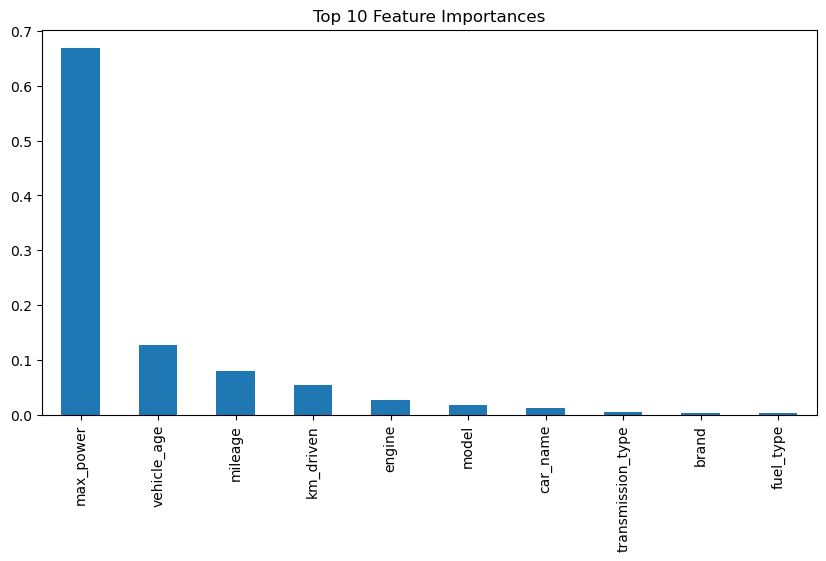

In [18]:
feature_importance.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Feature Importances")
plt.show()


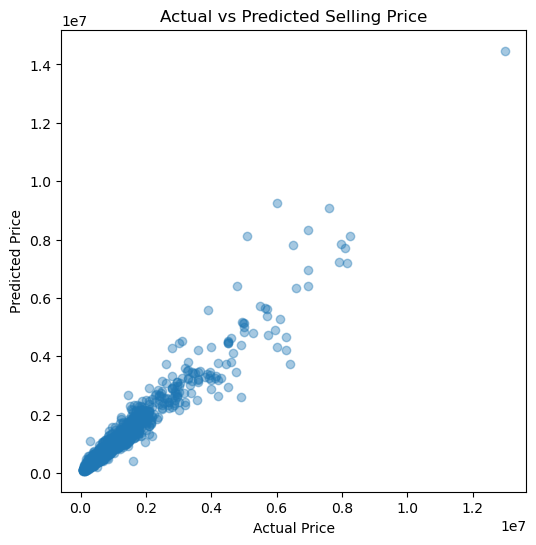

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Selling Price")
plt.show()
